# StageWaypoints Elevation Lookup

This notebook:
1. Reads `StageCode` and `Path` from the `StageWaypoints` table in `data/RC2K.db` (SQLite).
2. Parses each `Path` string (`x1,y1;x2,y2;...`) into a list of `(x, y)` coordinate pairs.
3. Calls the [Open-Meteo Elevation API](https://open-meteo.com/en/docs/elevation-api) to fetch elevation for every point (batched, max 100 coordinates per request).
4. Produces a combined DataFrame with `StageCode`, point index, `x`, `y`, and `elevation`.

> Note: In this dataset the pairs stored in `Path` are `longitude,latitude` (e.g. `-4.579871,54.120479`). The Open-Meteo API requires separate `latitude` and `longitude` arrays, so `x` is mapped to longitude and `y` to latitude below. Adjust the mapping if your data differs.

> **Free-tier rate limits (non-commercial use):** max **600 coords/minute**, **5,000/hour**, **10,000/day** ([terms](https://open-meteo.com/en/terms)). Each request can batch up to 100 coordinates, so the notebook throttles itself to stay under 6 requests/minute.

In [9]:
import sqlite3
import time
import requests
import pandas as pd
from collections import deque
from tqdm.auto import tqdm

DB_PATH = "../../data/RC2K.db"
ELEVATION_API_URL = "https://api.open-meteo.com/v1/elevation"
BATCH_SIZE = 100  # Open-Meteo allows up to 100 coordinates per request

# Free-tier rate limits (non-commercial use): 600 coords/minute, 5,000/hour, 10,000/day.
MAX_REQUESTS_PER_MINUTE = 6

# Only load/process stages with StageCode in [STAGE_CODE_MIN, STAGE_CODE_MAX] (inclusive).
# Set either to None to leave that side of the range unbounded (e.g. STAGE_CODE_MIN = None
# means "no lower bound"). Example: STAGE_CODE_MIN = 21, STAGE_CODE_MAX = 26 processes only
# stages 21..26.
STAGE_CODE_MIN = 61
STAGE_CODE_MAX = 66

## 1. Load StageCode and Path from SQLite

In [10]:
def load_stage_waypoints(db_path: str, stage_code_min: int = None, stage_code_max: int = None) -> pd.DataFrame:
    """Load StageCode/Path rows, optionally filtered to StageCode in [stage_code_min, stage_code_max]
    (inclusive on both ends; pass None on either side to leave that bound open).
    """
    query = 'SELECT StageCode, Path FROM StageWaypoints WHERE Path IS NOT NULL AND Path <> ""'
    conditions = []
    params = []
    if stage_code_min is not None:
        conditions.append("StageCode >= ?")
        params.append(stage_code_min)
    if stage_code_max is not None:
        conditions.append("StageCode <= ?")
        params.append(stage_code_max)
    if conditions:
        query += " AND " + " AND ".join(conditions)
    with sqlite3.connect(db_path) as con:
        df = pd.read_sql_query(query, con, params=params)
    return df


stages_df = load_stage_waypoints(DB_PATH, STAGE_CODE_MIN, STAGE_CODE_MAX)
print(f"Loaded {len(stages_df)} stage(s) with a Path value (StageCode range: {STAGE_CODE_MIN}..{STAGE_CODE_MAX}).")
stages_df.head()

Loaded 6 stage(s) with a Path value (StageCode range: 61..66).


,StageCode,Path
0,61,"-2.50068,55.094908;-2.500615,55.095073;-2.5005..."
1,62,"-2.374944,55.207985;-2.37495,55.208016;-2.375,..."
2,63,"-2.745472,55.119273;-2.745546,55.120472;-2.745..."
3,64,"-2.554287,55.100742;-2.554558,55.100817;-2.555..."
4,65,"-2.654044,55.330949;-2.654068,55.33094;-2.6543..."


## 2. Parse Path strings into (x, y) pairs

Format: pairs separated by `;`, and within each pair `x,y` separated by `,`.

In [11]:
def parse_path(path: str):
    """Parse a Path string like 'x1,y1;x2,y2;...' into a list of (x, y) float tuples."""
    points = []
    if not path:
        return points
    for pair in path.split(";"):
        pair = pair.strip()
        if not pair:
            continue
        x_str, y_str = pair.split(",")
        points.append((float(x_str), float(y_str)))
    return points


points_rows = []
for _, row in stages_df.iterrows():
    for idx, (x, y) in enumerate(parse_path(row["Path"])):
        points_rows.append({"StageCode": row["StageCode"], "PointIndex": idx, "x": x, "y": y})

points_df = pd.DataFrame(points_rows)

# Total number of (x, y) path points per stage, added as a column so it's visible alongside
# each row -- useful to gauge how many API requests a given StageCode range will need.
points_per_stage = points_df.groupby("StageCode")["PointIndex"].count().rename("PointsInStage")
points_df = points_df.merge(points_per_stage, on="StageCode", how="left")

print(f"Parsed {len(points_df)} total points across {points_df['StageCode'].nunique()} stage(s).")
print(f"You will have ~{-(-len(points_df) // BATCH_SIZE)} requests to API; limit for hour is 5k")
points_df.head()

Parsed 3335 total points across 6 stage(s).
You will have ~34 requests to API; limit for hour is 5k


,StageCode,PointIndex,x,y,PointsInStage
0,61,0,-2.500680,55.094908,626
1,61,1,-2.500615,55.095073,626
2,61,2,-2.500540,55.095368,626
3,61,3,-2.500551,55.095724,626
4,61,4,-2.500626,55.095957,626


## 3. Query elevation from Open-Meteo (batched, rate-limited)

`x` is treated as longitude and `y` as latitude. Requests are chunked to respect the 100-coordinate limit. A per-minute request counter throttles calls so we stay under Open-Meteo's free-tier limit of 600 requests/minute (also well under 5,000/hour and 10,000/day for typical dataset sizes).

In [12]:
class RateLimiter:
    """Enforces a minimum interval between calls. Keeps its state (last call time) across
    however many times it is invoked, so pacing is respected even if
    fetch_elevations_batched() is called multiple times (e.g. once per stage in a loop),
    instead of resetting on every call like a locally-scoped `last_request_time` would.
    """

    def __init__(self, max_requests_per_minute: int):
        self.min_interval = 60.0 / max_requests_per_minute
        self.last_call_time = None

    def wait(self):
        if self.last_call_time is not None:
            elapsed = time.monotonic() - self.last_call_time
            if elapsed < self.min_interval:
                time.sleep(self.min_interval - elapsed)
        self.last_call_time = time.monotonic()


# Shared across all calls to fetch_elevations_batched (e.g. across multiple stages),
# so the per-minute cap is respected globally, not just within a single call.
rate_limiter = RateLimiter(MAX_REQUESTS_PER_MINUTE)


def fetch_elevations(longitudes, latitudes, session: requests.Session = None):
    """Fetch elevation for parallel lists of longitudes/latitudes using Open-Meteo.

    On HTTP 429 (Too Many Requests), logs a message, waits 60 seconds, and retries the
    same call exactly once more before giving up.
    """
    session = session or requests.Session()
    params = {
        "longitude": ",".join(str(v) for v in longitudes),
        "latitude": ",".join(str(v) for v in latitudes),
    }
    try:
        response = session.get(ELEVATION_API_URL, params=params, timeout=30)
        response.raise_for_status()
    except requests.exceptions.HTTPError as exc:
        if exc.response is not None and exc.response.status_code == 429:
            print("Got 429 Too Many Requests from Open-Meteo. Waiting 60 seconds before retrying...")
            time.sleep(60)
            response = session.get(ELEVATION_API_URL, params=params, timeout=30)
            response.raise_for_status()
        else:
            raise
    data = response.json()
    if data.get("error"):
        raise RuntimeError(data.get("reason", "Unknown Open-Meteo error"))
    return data["elevation"]


def fetch_elevations_batched(
    df: pd.DataFrame,
    batch_size: int = BATCH_SIZE,
    limiter: RateLimiter = rate_limiter,
):
    """Fetch elevations for all rows in df (expects 'x' and 'y' columns), returning a list aligned with
    df's order. Uses `limiter` (shared by default) to throttle requests so no more than
    MAX_REQUESTS_PER_MINUTE calls are made in any 60-second window, keeping us under Open-Meteo's
    free-tier limit (600 req/min) -- even if this function is called repeatedly, e.g. once per stage.
    """
    elevations = [None] * len(df)
    session = requests.Session()
    batch_starts = list(range(0, len(df), batch_size))
    for start in tqdm(batch_starts, desc="Fetching elevations", unit="batch"):
        limiter.wait()
        chunk = df.iloc[start:start + batch_size]
        lons = chunk["x"].tolist()
        lats = chunk["y"].tolist()
        chunk_elevations = fetch_elevations(lons, lats, session=session)
        for offset, elevation in enumerate(chunk_elevations):
            elevations[start + offset] = elevation
    return elevations


points_df["elevation"] = fetch_elevations_batched(points_df)
points_df.head()

Fetching elevations:   0%|          | 0/34 [00:00<?, ?batch/s]

Fetching elevations: 100%|██████████| 34/34 [05:30<00:00,  9.71s/batch]


,StageCode,PointIndex,x,y,PointsInStage,elevation
0,61,0,-2.500680,55.094908,626,291.0
1,61,1,-2.500615,55.095073,626,288.0
2,61,2,-2.500540,55.095368,626,288.0
3,61,3,-2.500551,55.095724,626,288.0
4,61,4,-2.500626,55.095957,626,286.0


### Note on calling per stage

If you prefer to fetch elevations **stage by stage** (e.g. looping over `StageCode` and calling `fetch_elevations_batched` once per stage) rather than on the combined `points_df` above, that's fine — the throttling still applies correctly because `rate_limiter` is a shared, module-level `RateLimiter` instance. Its `last_call_time` persists across every call, so back-to-back calls (one per stage) still respect `MAX_REQUESTS_PER_MINUTE` overall. Example:

```python
results = []
for stage_code, group in points_df.groupby("StageCode"):
    group = group.copy()
    group["elevation"] = fetch_elevations_batched(group)  # uses the shared rate_limiter by default
    results.append(group)
points_df = pd.concat(results, ignore_index=True)
```

⚠️ Do **not** pass a fresh `RateLimiter(...)` instance per call (e.g. `fetch_elevations_batched(group, limiter=RateLimiter(...))`) — that would reset the throttle state each time and defeat the purpose, causing bursts across stages.

## 4. Inspect / summarize results

In [13]:
points_df.groupby("StageCode")["elevation"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
StageCode,,,,
61,173.0,335.0,248.161342,626
62,184.0,429.0,292.079505,566
63,144.0,457.0,260.088929,551
64,198.0,426.0,293.545076,721
65,257.0,453.0,344.368627,255
66,155.0,323.0,231.488636,616


## 5. (Optional) Save results to CSV

In [14]:
points_df.to_csv(f"stage_waypoints_elevation_{STAGE_CODE_MIN}_{STAGE_CODE_MAX}.csv", index=False)
print(f"Saved stage_waypoints_elevation_{STAGE_CODE_MIN}_{STAGE_CODE_MAX}.csv")

Saved stage_waypoints_elevation_61_66.csv


## 6. Load elevation results from CSV

Reload the previously saved `stage_waypoints_elevation.csv` into a fresh DataFrame -- useful if you want to
continue analysis/plotting later without re-running the API calls above.

In [37]:
CSV_PATH = "stage_waypoints_elevation.csv"

points_df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(points_df)} rows across {points_df['StageCode'].nunique()} stage(s) from {CSV_PATH}.")
points_df.head()

Loaded 2998 rows across 6 stage(s) from stage_waypoints_elevation.csv.


,StageCode,PointIndex,x,y,PointsInStage,elevation
0,21,0,-4.579871,54.120479,465,82.0
1,21,1,-4.579825,54.120370,465,82.0
2,21,2,-4.579616,54.119830,465,74.0
3,21,3,-4.579590,54.119721,465,74.0
4,21,4,-4.579580,54.119660,465,74.0


## 7. Compute distance along path (in meters)

`x`/`y` are WGS84 longitude/latitude in degrees, so a naive Euclidean (Pythagoras) distance on the raw
degree values would be wrong: a degree of longitude and a degree of latitude do not correspond to the
same physical distance, and that ratio changes with latitude. Instead we use the **Haversine formula**,
which accounts for the Earth's curvature, to get the great-circle distance in meters between each pair of
consecutive points along a stage's path. Cumulatively summing these gives `DistanceAlongPath`: the offset
in meters from the start of each stage, used as the x-axis in the plot below instead of the raw point index.

In [8]:
import numpy as np

EARTH_RADIUS_METERS = 6371000.0


def haversine_distance_meters(lon1, lat1, lon2, lat2):
    """Great-circle distance in meters between (lon1, lat1) and (lon2, lat2), given in degrees."""
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return EARTH_RADIUS_METERS * c


def add_distance_along_path(df: pd.DataFrame) -> pd.DataFrame:
    """Adds a 'DistanceAlongPath' column (meters from the first point) computed per StageCode,
    using the Haversine distance between consecutive (x=lon, y=lat) points ordered by PointIndex.
    """
    df = df.sort_values(["StageCode", "PointIndex"]).copy()
    distances = np.zeros(len(df))
    for _, group in df.groupby("StageCode"):
        idx = group.index
        lon = group["x"].to_numpy()
        lat = group["y"].to_numpy()
        segment_lengths = haversine_distance_meters(lon[:-1], lat[:-1], lon[1:], lat[1:])
        cumulative = np.concatenate(([0.0], np.cumsum(segment_lengths)))
        distances[df.index.get_indexer(idx)] = cumulative
    df["DistanceAlongPath"] = distances
    return df


points_df = add_distance_along_path(points_df)
points_df[["StageCode", "PointIndex", "x", "y", "DistanceAlongPath"]].head()

,StageCode,PointIndex,x,y,DistanceAlongPath
0,31,0,-3.229521,55.265410,0.000000
1,31,1,-3.230679,55.265955,95.158140
2,31,2,-3.230873,55.266190,124.035210
3,31,3,-3.230898,55.266581,167.541267
4,31,4,-3.230802,55.266816,194.370538


## 8. Plot elevation profile per stage

Draws one elevation-vs-distance-along-path line per `StageCode`, each on its own subplot,
using `DistanceAlongPath` (meters from the start of the stage, via the Haversine formula) as the x-axis.

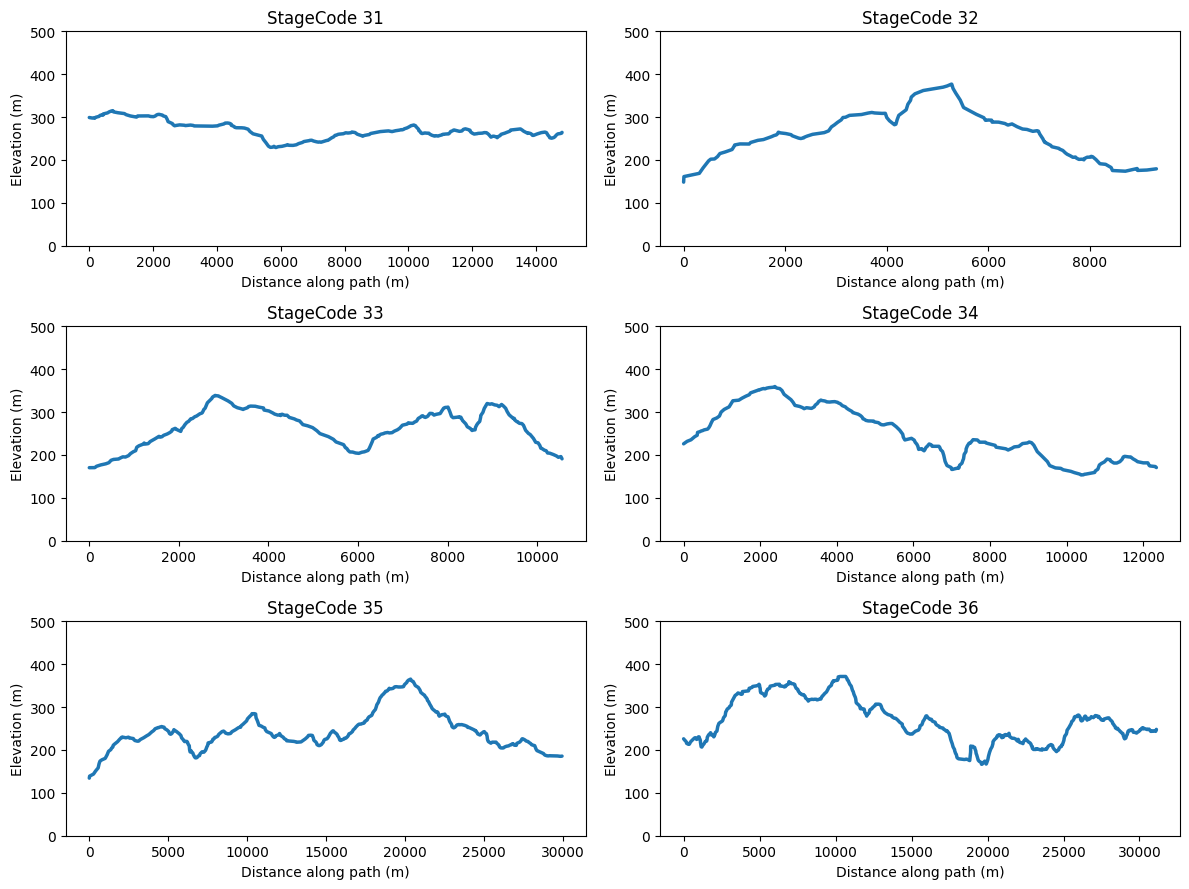

In [9]:
import matplotlib.pyplot as plt

# Rolling-average window applied to elevation before plotting, purely for a smoother,
# rounder-looking curve (does not change the underlying data).
SMOOTHING_WINDOW = 5

stage_codes = sorted(points_df["StageCode"].unique())
n_stages = len(stage_codes)
n_cols = 2
n_rows = -(-n_stages // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3 * n_rows), squeeze=False)

for ax, stage_code in zip(axes.flat, stage_codes):
    stage_points = points_df[points_df["StageCode"] == stage_code].sort_values("PointIndex")
    smoothed_elevation = (
        stage_points["elevation"]
        .rolling(window=SMOOTHING_WINDOW, min_periods=1, center=True)
        .mean()
    )
    ax.plot(
        stage_points["DistanceAlongPath"],
        smoothed_elevation,
        linewidth=2.5,
        solid_capstyle="round",
        solid_joinstyle="round",
    )
    ax.set_title(f"StageCode {stage_code}")
    ax.set_xlabel("Distance along path (m)")
    ax.set_ylabel("Elevation (m)")
    ax.set_ylim(0, 500)

# Hide any unused subplot axes (when n_stages doesn't evenly fill the grid).
for ax in axes.flat[n_stages:]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()